In [1]:
## Test GPU
import torch

def get_device():
    """Get the appropriate device for model inference."""
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()

print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 
# STICK to localhost:44123 

You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [3]:
fo.list_datasets()

['FLPLAN', 'dugong', 'flplanpatches']

In [4]:
from dotenv import load_dotenv
load_dotenv()

import fiftyone as fo
import fiftyone.utils.torch as fout
from huggingface_hub import login

if "HUGGING_FACE_API" in os.environ:
    login(token=os.environ["HUGGING_FACE_API"])

In [5]:
client = fo.core.odm.database.get_db_client()
print(client)  # Should show localhost:44123

MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone')


In [5]:
print(fo.config)

{
    "allow_legacy_orchestrators": false,
    "batcher_static_size": 100,
    "batcher_target_latency": 0.2,
    "batcher_target_size_bytes": 1048576,
    "database_admin": true,
    "database_compressor": null,
    "database_dir": "/share/home/e2406743/.fiftyone/var/lib/mongo",
    "database_name": "fiftyone",
    "database_uri": "mongodb://localhost:44123",
    "database_validation": true,
    "dataset_zoo_dir": "/share/home/e2406743/fiftyone",
    "dataset_zoo_manifest_paths": null,
    "default_app_address": "localhost",
    "default_app_port": 5151,
    "default_batch_size": null,
    "default_batcher": "latency",
    "default_dataset_dir": "/share/home/e2406743/fiftyone",
    "default_image_ext": ".jpg",
    "default_ml_backend": "torch",
    "default_parallelization_method": null,
    "default_process_pool_workers": null,
    "default_sequence_idx": "%06d",
    "default_thread_pool_workers": null,
    "default_video_ext": ".mp4",
    "delegated_operation_monitor_interval": 60,


In [6]:
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F
import fiftyone.operators as foo
from fiftyone.utils.huggingface import load_from_hub
import cv2
import numpy as np
import fiftyone.brain as fob
import fiftyone.utils.transformers as fout

In [7]:
    print(fo.core.odm.database.get_db_conn())
    print(fo.core.odm.database.get_db_client())

Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')
MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone')


In [7]:
dataset = fo.load_dataset("FLPLAN")

## load the views
# nc_view = dataset.load_saved_view("nc")
# wp_view = dataset.load_saved_view("wp")

In [8]:
next(iter(dataset))

<Sample: {
    'id': '6a155c1000810aef404b021f',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_P4P_UM_M15_F1_2025_GSP-697622d8e60f0_26_03_09/images/FPLAN_P4P_UM_M15_F1_2025_GSP-697622d8e60f0_10.jpeg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 538898,
        'mime_type': 'image/jpeg',
        'width': 5472,
        'height': 3648,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 5, 26, 8, 38, 40, 23000),
    'last_modified_at': datetime.datetime(2026, 5, 28, 8, 25, 19, 578000),
    'region': 'WP',
    'mission_name': 'UM',
    'parent_name': 'FPLAN_P4P_UM_M15_F1_2025_GSP-697622d8e60f0_26_03_09',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a155c0f00810aef404b01c9',
                'attributes': {},
                'tags': [],
                'label': 'Dugong',
                'bounding_box': [0.292215, 0.11

In [36]:
dataset.first()['flight_mission'].split('_')

['FPLAN', 'P4P', 'UM', 'M15', 'F1', '2025', 'GSP']

In [37]:
# add new field
for sample in dataset.iter_samples(progress=True):
    parent_name = sample['parent_name']
    sample['flight_mission'] = str(parent_name).split('-')[0]
    sample['m_flight'] = sample['flight_mission'].split('_')[3]
    
    sample.save()



   5% |/------------------|  4/83 [148.0ms elapsed, 2.9s remaining, 27.0 samples/s] 

 100% |███████████████████| 83/83 [2.0s elapsed, 0s remaining, 44.9 samples/s]      


In [38]:
dataset.count_values('m_flight')

{'M48': 8,
 'M33': 9,
 'M40': 19,
 'M13': 11,
 'M4': 2,
 'M46': 14,
 'M15': 10,
 'M35': 10}

In [11]:
## Session launch

In [25]:
# On a cluster: auto=False prevents it trying to open a browser
# Use port forwarding: ssh -L 5151:localhost:5151 user@cluster
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)
print(session.url)  


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.
http://localhost:5151/


## Model & Processor

In [ ]:
from transformers import AutoImageProcessor, AutoModel
import fiftyone.utils.transformers as fout

processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vitl16-pretrain-lvd1689m")
base_model = AutoModel.from_pretrained("facebook/dinov3-vitl16-pretrain-lvd1689m")

# Convert using the transformers utility
# defaults to feature extraction
model = fout.convert_transformers_model(base_model, 
                                        image_processor=processor)

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [12]:
processor

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

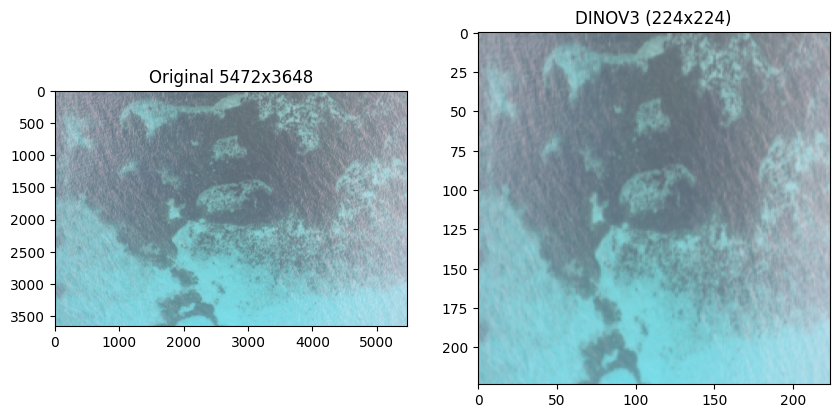

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Grab a sample (e.g., one with a clear Dugong)
sample = dataset.skip(50).first()
img = Image.open(sample.filepath)

# 2. Run the processor manually (as FiftyOne does internally)
inputs = processor(img, 
                   return_tensors="pt")
# Extract pixels, move to CPU, and convert to (H, W, C) for plotting
v_img = inputs["pixel_values"].squeeze(0).permute(1, 2, 0).numpy()

# 3. "Un-normalize" so the colors look normal
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
v_img = (v_img * std) + mean
v_img = np.clip(v_img, 0, 1)

#get metadata
# 4. Plot Comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original {img.width}x{img.height}")
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.title("DINOV3 (224x224)")
plt.imshow(v_img)
plt.show()

In [13]:
print(model)

## Patch Embeddings

In [ ]:
import fiftyone.core.models as fom

class DinoV3PatchModel(fom.Model):

    def __init__(self, model, processor, device=None):
        self.model = model
        self.processor = processor
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()

    @property
    def media_type(self):
        return "image"

    @property
    def has_logits(self):
        return False

    @property
    def has_embeddings(self):
        return True

    @property
    def ragged_batches(self):
        return False

    @property
    def transforms(self):
        return None  # Let embed() handle everything

    def _preprocess(self, img):
        """Convert any input format to a processor-ready PIL image."""
        from PIL import Image
        import numpy as np
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()
        if isinstance(img, np.ndarray):
            if img.dtype != np.uint8:
                img = (img * 255).clip(0, 255).astype(np.uint8)
            img = Image.fromarray(img)
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        return img.convert("RGB")

    def embed(self, img):
        pil = self._preprocess(img)
        inputs = self.processor(images=pil, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)  # (1, 3, H, W)
        with torch.inference_mode():
            outputs = self.model(pixel_values=pixel_values)
        return outputs.pooler_output.squeeze(0).cpu().numpy()

    def embed_all(self, imgs):
        from PIL import Image
        pil_imgs = [self._preprocess(img) for img in imgs]
        inputs = self.processor(images=pil_imgs, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)  # (B, 3, H, W)
        with torch.inference_mode():
            outputs = self.model(pixel_values=pixel_values)
        return outputs.pooler_output.cpu().numpy()




In [ ]:
model = DinoV3PatchModel(base_model, processor)
# Run
patch_embeddings = dataset.compute_patch_embeddings(
    model,
    patches_field="ground_truth",
    embeddings_field="patch_embeddings",
    num_workers=0,
    progress=True,
)

In [12]:
patch_results = fob.compute_visualization(
    dataset,
    patches_field="ground_truth",
    embeddings="patch_embeddings",
    method="tsne",
    brain_key="patch_emb_dinov3_tsne",
    create_index=True,   
    seed=42,
    max_iter = 2000, 
    progress=True,
)

Generating visualization...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7161 samples in 0.001s...
[t-SNE] Computed neighbors for 7161 samples in 0.304s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7161
[t-SNE] Computed conditional probabilities for sample 2000 / 7161
[t-SNE] Computed conditional probabilities for sample 3000 / 7161
[t-SNE] Computed conditional probabilities for sample 4000 / 7161
[t-SNE] Computed conditional probabilities for sample 5000 / 7161
[t-SNE] Computed conditional probabilities for sample 6000 / 7161
[t-SNE] Computed conditional probabilities for sample 7000 / 7161
[t-SNE] Computed conditional probabilities for sample 7161 / 7161
[t-SNE] Mean sigma: 2.444409
[t-SNE] Computed conditional probabilities in 0.130s
[t-SNE] Iteration 50: error = 85.2473755, gradient norm = 0.0108855 (50 iterations in 0.452s)
[t-SNE] Iteration 100: error = 82.8385010, gradient norm = 0.0008517 (50 iterations in 0.370s)
[t-SNE] Iteration 150: error = 8

In [16]:
## plot results 
# Visualize embeddings, colored by ground truth label
plot = patch_results.visualize(labels="ground_truth.detections.subregion")
plot.show(height=720)

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['69add897cfd942e1c6b5c976', '69add897cfd942e1c6b5c977',
                                   '69add897cfd942e1c6b5c978', ..., '69add897cfd942e1c6b5ce8e',
                                   '69add897cfd942e1c6b5ce8f', '69add897cfd942e1c6b5ce90'],
                                  shape=(1307,), dtype=object),
              'hovertemplate': ('<b>subregion: %{text}</b><br>x' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': np.str_('FRIWEN'),
              'showlegend': True,
              'text': array(['FRIWEN', 'FRIWEN', 'FRIWEN', ..., 'FRIWEN', 'FRIWEN', 'FRIWEN'],
                            shape=(1307,), dtype=object),
              'type': 'scattergl',
              'uid': '5cda597e-4e28-4bef-a6e7-f9c5085933bf',
              'x': {'bdata': ('PmUcwaA2/UH/XABCnwT+Qa1nD0IENQ' ... '1C4nohQklq9UF69axBIir5QfRq+UE='),
                    'dtype': 'f4'},

### Alpha Patch Embeddings

expansion/contraction to apply to the patches before extracting them, in [-1, inf). If provided, the length and width of the box are expanded (or contracted, when alpha < 0) by (100 * alpha)%. For example, set alpha = 0.1 to expand the boxes by 10%, and set alpha = -0.1 to contract the boxes by 10%

In [ ]:
## CLEAN OLD FIELD
# To delete 'patch10_dinov3_umap' from all detections
dataset.clear_sample_field("ground_truth.detections.patch10_dinov3_umap")

# To delete '10_patch_embeddings'
dataset.clear_sample_field("ground_truth.detections.10_patch_embeddings")

In [16]:
# This completely removes the field from the dataset's 'memory'
dataset.delete_sample_field("ground_truth.detections.patch10_dinov3_umap")
dataset.delete_sample_field("ground_truth.detections.10_patch_embeddings")

In [18]:
model = DinoV3PatchModel(base_model, processor)

# compute over a loop

# Run
for perc in [0.1, 0.25, 0.5, 0.75, 1.0]:
    print(f"Run for:{perc*100}%")
    patch_embeddings = dataset.compute_patch_embeddings(
        model,
        patches_field="ground_truth",
        embeddings_field=f"patch_{str(int(perc*100))}expansion_embeddings",
        alpha = perc,
        num_workers=0,
        progress=True,
    )

Run for:10.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.8m elapsed, 0s remaining, 6.9 samples/s]       
Run for:25.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.7m elapsed, 0s remaining, 5.6 samples/s]       
Run for:50.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.8m elapsed, 0s remaining, 6.5 samples/s]       
Run for:75.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.8m elapsed, 0s remaining, 6.1 samples/s]       
Run for:100.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [5.1m elapsed, 0s remaining, 7.0 samples/s]       


In [11]:
session.open_tab()

<IPython.core.display.Javascript object>

In [12]:
session.close()

In [12]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 9, 9, 22, 52, 329000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
      

## Full Embeddings

In [21]:
embeddings = dataset.compute_embeddings(
    model,
    embeddings_field='full_embeddings',
    num_workers =2,
    batch_size=4,
    progress=True,  
)

 100% |███████████████████| 83/83 [22.2s elapsed, 0s remaining, 4.4 samples/s]    


In [22]:
## compute visualization 
full_emb_results = fob.compute_visualization(
    dataset,
    embeddings="full_embeddings",
    method="umap",
    brain_key="full_emb_umap_dinov3",
    create_index=True,   
    seed=42,
    progress=True,
    max_iters = 1500
)

Generating visualization...


/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Thu May 28 13:56:51 2026 Construct fuzzy simplicial set
Thu May 28 13:56:51 2026 Finding Nearest Neighbors
Thu May 28 13:56:57 2026 Finished Nearest Neighbor Search
Thu May 28 13:57:00 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu May 28 13:57:02 2026 Finished embedding
Generating spatial index in field 'full_emb_umap_dinov3'...
 100% |███████████████████| 83/83 [10.6ms elapsed, 0s remaining, 7.8K samples/s]      


In [24]:
## plot results 
# Visualize embeddings, colored by ground truth label
plot = full_emb_results.visualize()
plot.show(height=720)

#session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['6a155c1000810aef404b021f', '6a155c1000810aef404b0220',
                                   '6a155c1000810aef404b0221', '6a155c1000810aef404b0222',
                                   '6a155c1000810aef404b0223', '6a155c1000810aef404b0224',
                                   '6a155c1000810aef404b0225', '6a155c1000810aef404b0226',
                                   '6a155c1000810aef404b0227', '6a155c1000810aef404b0228',
                                   '6a155c1000810aef404b0229', '6a155c1000810aef404b022a',
                                   '6a155c1000810aef404b022b', '6a155c1000810aef404b022c',
                                   '6a155c1000810aef404b022d', '6a155c1000810aef404b022e',
                                   '6a155c1000810aef404b022f', '6a155c1000810aef404b0230',
                                   '6a155c1000810aef404b0231', '6a155c1000810aef404b0232',
                                   '6a155c1000810aef404b0233', '6a155c10008

In [29]:
# Plot inline (if in Jupyter with display support)
plot = results.visualize(labels="ground_truth.detections.region")
plot.show()

FigureWidget({
    'data': [{'customdata': array(['69add895cfd942e1c6b5b7b4', '69add895cfd942e1c6b5b7b5',
                                   '69add895cfd942e1c6b5b7b6', ..., '69add896cfd942e1c6b5c58b',
                                   '69add896cfd942e1c6b5c58c', '69add896cfd942e1c6b5c58d'],
                                  shape=(3546,), dtype=object),
              'hovertemplate': ('<b>region: %{text}</b><br>x, y' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': np.str_('NC'),
              'showlegend': True,
              'text': array(['NC', 'NC', 'NC', ..., 'NC', 'NC', 'NC'], shape=(3546,), dtype=object),
              'type': 'scattergl',
              'uid': '6f06bd37-0622-4c18-8a0f-2ed2b9234a3d',
              'x': {'bdata': ('+ejswdzZQsHeZEPBmexCwRFzQ8EKVN' ... 'yFwVTuwsGU9bZBhXUTwguipEGGYw5C'),
                    'dtype': 'f4'},
              'y': {'bdata': ('K/ccQmxtnEG9jJtBeQydQVMG

In [31]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 8, 20, 51, 20, 872683),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
     

In [32]:
fo.close_app()

In [28]:
for sample in dataset.iter_samples(autosave=True, progress=True):
    region = sample["region"]
    if sample.ground_truth and sample.ground_truth.detections:
        for det in sample.ground_truth.detections:
            det["region"] = region

 100% |███████████████| 2755/2755 [7.7s elapsed, 0s remaining, 623.9 samples/s]       


In [ ]:
# DINOv3
from transformers import Dinov2ForImageClassification
model = Dinov2ForImageClassification.from_pretrained(
    "facebook/dinov2-small-imagenet1k-1-layer"
)

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

In [19]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 20, 13, 25, 40, 636000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
    

## Compute Embeddings

In [ ]:
# compute embeedings for the given model
embeddings  = dataset.compute_embeddings(model,
                                        batch_size=256,
                                        num_workers=0,
                                        embeddings_field="embeddings",
                                        progress=True)



 100% |███████████████| 2755/2755 [4.7m elapsed, 0s remaining, 8.8 samples/s]     


### save embeddings back in the shared folder 

In [ ]:
folder_root = "/share/projects/embeddings/"
model_emb ="dinov2"
name_emb = f"full_embeddings.npy"

## create dir in case doesnt exist
os.makedirs(os.path.join(folder_root, model_emb), exist_ok=True)

## save embeddings back in the share storage
np.save(os.path.join(folder_root, model_emb, name_emb), embeddings)

print("Embeddings saved to shared storage!")

In [ ]:
results = fob.compute_visualization(
     dataset,
     embeddings=embeddings,
     method="tsne",
     brain_key="dino_viz",
  ##  pre_pca=50, # Reduces dimensions to 50 before running t-SNE
 )


# Plot embeddings

In [ ]:
## compute visualization 
full_emb_results = fob.compute_visualization(
    dataset,
    embeddings="full_embeddings",
    method="umap",
    brain_key="full_emb_umap_dinov3",
    create_index=True,   
    seed=42,
    progress=True,
    max_iters = 1500,
    num_neighbors = 20,
    metric = 'cosine'
)